# **02477 Bayesian Machine Learning — Exam 2024 Complete Guide**

This notebook contains fully worked solutions for all 5 parts of the 2024 exam, with step-by-step explanations of *why* each step is taken, not just what the answer is. Key formulas are highlighted in orange — these are the ones worth memorising.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn

np.random.seed(42)

# Data and hyperparameters used throughout Part 2
x = np.array([-2.17, 1.99,  0.57, -3.01, -1.16, 3.30, -4.85, -0.86])
y = np.array([ 0.88, 0.46, -0.06,  0.98,  0.45, 0.88, -0.66,  0.05])
N = len(x)

kappa = 0.7
ell   = 0.5 * np.sqrt(2)
sigma = 0.2

# Squared-exponential kernel (scalar or vectorised)
def k1(x1, x2):
    return kappa**2 * np.exp(-0.5 * (x1 - x2)**2 / ell**2)

# Build NxN or NxM kernel matrix
def build_K(xa, xb, jitter=1e-8):
    K = k1(xa[:, None], xb[None, :])
    if xa is xb or np.array_equal(xa, xb):
        K += jitter * np.eye(len(xa))
    return K

K = build_K(x, x)
C = K + sigma**2 * np.eye(N)   # C = K + sigma^2 * I  (used repeatedly)


---
### **Part 1: Linear Gaussian Systems**

Consider the Markov chain:
$$x_1 \sim \mathcal{N}(0, \Sigma) \tag{1}$$
$$x_2|x_1 \sim \mathcal{N}(Ax_1, \Sigma) \tag{2}$$
$$x_3|x_2 \sim \mathcal{N}(Ax_2, \Sigma) \tag{3}$$
where $A \in \mathbb{R}^{2\times2}$ and $\Sigma \in \mathbb{R}^{2\times2}$ are constants.

##### **Question 1.1: Determine the conditional distribution of $x_1$ given $x_2$.**

We have to find $p(x_1|x_2)$. Looking at equations $(1)$ and $(2)$, we recognise this as a **linear Gaussian system** — the key words to search for in the lecture notes. The general form is:
$$p(y|z) = \mathcal{N}(y|Wz+b, \Sigma_y)$$
$$p(z) = \mathcal{N}(z|\mu_z, \Sigma_z)$$

Here $p(z) = p(x_1)$ and $p(y|z) = p(x_2|x_1)$, so we want $p(z|y) = p(x_1|x_2)$. The formulas for a linear Gaussian conditional are:

<span style="color: orange;">

$$p(z|y) = \mathcal{N}(z|\mu_{z|y}, \Sigma_{z|y}) \tag{1a}$$
$$\Sigma_{z|y}^{-1} = \Sigma_z^{-1} + W^T\Sigma_y^{-1}W \tag{1b}$$
$$\mu_{z|y} = \Sigma_{z|y}\left[W^T\Sigma_y^{-1}(y - b) + \Sigma_z^{-1}\mu_z\right] \tag{1c}$$

</span>

**Step 1 — Identify all components** by matching our model to the general form ($z=x_1$, $y=x_2$):
$$W = A \quad \text{from} \quad x_2|x_1 \sim \mathcal{N}(Ax_1, \Sigma) \quad \text{(the matrix in front of } z \text{)}$$
$$b = 0 \quad \text{from} \quad x_2|x_1 \sim \mathcal{N}(Ax_1 + 0, \Sigma) \quad \text{(no offset term)}$$
$$\Sigma_y = \Sigma \quad \text{from} \quad x_2|x_1 \sim \mathcal{N}(Ax_1, \Sigma) \quad \text{(noise covariance of the observation)}$$
$$\Sigma_z = \Sigma \quad \text{from} \quad x_1 \sim \mathcal{N}(0, \Sigma) \quad \text{(prior covariance)}$$
$$\mu_z = 0 \quad \text{from} \quad x_1 \sim \mathcal{N}(0, \Sigma) \quad \text{(prior mean)}$$

**Step 2 — Compute $\Sigma_{x_1|x_2}$** using equation $(1b)$:
$$\Sigma_{x_1|x_2}^{-1} = \Sigma^{-1} + A^T\Sigma^{-1}A$$
Inverting both sides:
$$\Sigma_{x_1|x_2} = (\Sigma^{-1} + A^T\Sigma^{-1}A)^{-1}$$

**Step 3 — Compute $\mu_{x_1|x_2}$** using equation $(1c)$, inserting $b=0$ and $\mu_z=0$:
$$\mu_{x_1|x_2} = \Sigma_{x_1|x_2}\left[A^T\Sigma^{-1}(x_2 - 0) + \Sigma^{-1}\cdot 0\right] = \Sigma_{x_1|x_2}\,A^T\Sigma^{-1}x_2$$

**Step 4 — Write the final answer** by substituting into $(1a)$:
$$\boxed{p(x_1|x_2) = \mathcal{N}\!\left(x_1 \;\Big|\; \Sigma_{x_1|x_2}A^T\Sigma^{-1}x_2,\; (\Sigma^{-1}+A^T\Sigma^{-1}A)^{-1}\right)}$$

**We have now derived the conditional distribution of $x_1$ given $x_2$.**

##### **Question 1.2: Determine the marginal distribution of $x_3$, i.e. $p(x_3)$.**

We need $p(x_3)$. Since $x_3$ depends on $x_2$ (not directly on $x_1$), we must first find $p(x_2)$ and then integrate again. The key formula for marginalising a linear Gaussian is:

<span style="color: orange;">

$$p(y) = \int p(y|z)\,p(z)\,dz = \mathcal{N}(y\,|\,W\mu_z + b,\; \Sigma_y + W\Sigma_z W^T) \tag{2a}$$

</span>

The intuition: the mean of $y$ is $W$ times the mean of $z$ (plus $b$), and the covariance has two sources — the inherent noise $\Sigma_y$ and the propagated uncertainty from $z$ through $W$.

**Step 1 — Find $p(x_2)$** by marginalising out $x_1$. We match $p(x_2|x_1) = \mathcal{N}(x_2|Ax_1,\Sigma)$ and $p(x_1) = \mathcal{N}(x_1|0,\Sigma)$ to the general form ($y=x_2$, $z=x_1$):
$$W = A, \quad \mu_z = 0, \quad b = 0, \quad \Sigma_y = \Sigma, \quad \Sigma_z = \Sigma$$

Inserting into $(2a)$:
$$p(x_2) = \mathcal{N}(x_2\,|\,A\cdot 0 + 0,\; \Sigma + A\Sigma A^T) = \mathcal{N}(x_2\,|\,0,\; \Sigma + A\Sigma A^T) \tag{2b}$$

**Step 2 — Find $p(x_3)$** by marginalising out $x_2$. Now match $p(x_3|x_2) = \mathcal{N}(x_3|Ax_2,\Sigma)$ and $p(x_2)$ from $(2b)$ to the general form ($y=x_3$, $z=x_2$):
$$W = A \quad \text{from} \quad x_3|x_2 \sim \mathcal{N}(Ax_2,\Sigma)$$
$$\mu_z = 0, \quad b = 0 \quad \text{from} \quad p(x_2) = \mathcal{N}(x_2|0, \Sigma+A\Sigma A^T)$$
$$\Sigma_y = \Sigma \quad \text{from} \quad x_3|x_2 \sim \mathcal{N}(Ax_2,\Sigma)$$
$$\Sigma_z = \Sigma + A\Sigma A^T \quad \text{from} \quad p(x_2) = \mathcal{N}(x_2|0, \Sigma+A\Sigma A^T)$$

Inserting into $(2a)$:
$$p(x_3) = \mathcal{N}(x_3\,|\,A\cdot 0+0,\; \Sigma + A(\Sigma + A\Sigma A^T)A^T)$$

Multiplying out the parentheses:
$$\boxed{p(x_3) = \mathcal{N}(x_3\,|\,0,\; \Sigma + A\Sigma A^T + AA\Sigma A^T A^T)}$$

**We have now derived the marginal distribution of $x_3$.**

##### **Question 1.3: Determine the conditional distribution of $x_3$ given $x_1$.**

We need $p(x_3|x_1)$. $x_3$ does not directly depend on $x_1$ — it only depends on $x_1$ *through* $x_2$. The trick is to use the Markov chain structure to write the joint and then marginalise out $x_2$.

**Step 1 — Write the joint $p(x_1,x_2,x_3)$** using the Markov chain factorisation:

<span style="color: orange;">

$$p(x_1, x_2, x_3) = p(x_3|x_2)\,p(x_2|x_1)\,p(x_1) \tag{3a}$$

</span>

This works because the chain structure means $x_3 \perp x_1 \mid x_2$ — given $x_2$, knowing $x_1$ gives no extra information about $x_3$.

**Step 2 — Marginalise out $x_2$** to get the joint of $(x_1, x_3)$:
$$p(x_1, x_3) = \int p(x_3|x_2)\,p(x_2|x_1)\,p(x_1)\,dx_2 = p(x_1) \int \mathcal{N}(x_3|Ax_2,\Sigma)\,\mathcal{N}(x_2|Ax_1,\Sigma)\,dx_2$$

We can pull $p(x_1)$ outside the integral because it does not depend on $x_2$.

**Step 3 — Read off $p(x_3|x_1)$**. Since $p(x_1,x_3) = p(x_1)\,p(x_3|x_1)$, the integral *must equal* $p(x_3|x_1)$:
$$p(x_3|x_1) = \int \mathcal{N}(x_3|Ax_2,\Sigma)\,\mathcal{N}(x_2|Ax_1,\Sigma)\,dx_2$$

**Step 4 — Solve the integral** using formula $(2a)$ again. Match $p(y|z) = \mathcal{N}(x_3|Ax_2,\Sigma)$ and $p(z) = \mathcal{N}(x_2|Ax_1,\Sigma)$ — we treat $x_1$ as a constant here, so $\mu_z = Ax_1$:
$$W = A, \quad \mu_z = Ax_1, \quad b = 0, \quad \Sigma_y = \Sigma, \quad \Sigma_z = \Sigma$$

Inserting into $(2a)$:
$$p(x_3|x_1) = \mathcal{N}(x_3\,|\,A(Ax_1)+0,\; \Sigma + A\Sigma A^T) = \mathcal{N}(x_3\,|\,A^2x_1,\; \Sigma + A\Sigma A^T)$$

$$\boxed{p(x_3|x_1) = \mathcal{N}(x_3\,|\,A^2x_1,\; \Sigma + A\Sigma A^T)}$$

The mean $A^2 x_1$ makes intuitive sense: propagating $x_1$ through the chain twice ($x_1 \to x_2 \to x_3$) multiplies by $A$ each time.

**We have now derived the conditional distribution of $x_3$ given $x_1$.**

---
### **Part 2: Gaussian Process Regression**

Model: $y_n = f(x_n) + \epsilon_n$, where $f \sim \mathcal{GP}(0, k_1(x,x'))$ and $\epsilon_n \sim \mathcal{N}(0,\sigma^2)$ i.i.d.

Kernel: $k_1(x,x') = \kappa^2 \exp\!\left(-\dfrac{\|x-x'\|^2}{2\ell^2}\right)$

Hyperparameters: $\kappa=0.7$, $\ell=\tfrac{\sqrt{2}}{2}$, $\sigma=\tfrac{1}{5}$

Dataset ($N=8$): $x=[-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86]$, $y=[0.88, 0.46, -0.06, 0.98, 0.45, 0.88, -0.66, 0.05]$

##### **Question 2.1: Determine the likelihood for the regression model in eq. (4).**

The model says $y_n = f(x_n) + \epsilon_n$ with $\epsilon_n \sim \mathcal{N}(0,\sigma^2)$. Rearranging: $y_n - f(x_n) = \epsilon_n$, so conditioned on $f(x_n)$, $y_n$ is just a Gaussian centred at $f(x_n)$:
$$p(y_n|f(x_n)) = \mathcal{N}(y_n|f(x_n), \sigma^2)$$

Since the noise is i.i.d., the observations are conditionally independent given $f$, so the joint likelihood factors into a product:
$$p(y|f) = \prod_{n=1}^N \mathcal{N}(y_n|f(x_n),\sigma^2)$$

Writing this product as a single multivariate Gaussian (stacking all $y_n$ into a vector $y$ and all $f(x_n)$ into a vector $f$):
$$\boxed{p(y|f) = \mathcal{N}(y|f,\sigma^2 I)}$$

The $\sigma^2 I$ covariance reflects that the noise on each observation is independent (off-diagonal zeros) and has the same variance $\sigma^2$ (diagonal entries).

**This is the end of question 2.1.**

##### **Question 2.2: Determine the analytical prior predictive distribution $p(y^*|x^*=1)$ for $y^* = y(x^*)$.**

The **prior predictive** answers: before seeing any data, what distribution do we expect for a new observation $y^*$ at $x^*$?

We write $y^* = f(x^*) + \epsilon^*$ and need to integrate out both the unknown function value $f(x^*)$ and the noise $\epsilon^*$.

Since the GP prior says $f(x^*) \sim \mathcal{N}(0, k_1(x^*,x^*))$ and noise $\epsilon^* \sim \mathcal{N}(0,\sigma^2)$, and these are independent, we just add variances:

<span style="color: orange;">

$$p(y^*|x^*) = \mathcal{N}(y^*|0,\; k_1(x^*,x^*) + \sigma^2)$$

</span>

Now we evaluate at $x^*=1$. When $x^* = x^{*'}$, the distance $\|x^* - x^*\| = 0$, so the exponential equals 1 and:
$$k_1(1,1) = \kappa^2 \exp(0) = \kappa^2 = 0.7^2 = 0.49$$

Therefore the total variance is:
$$k_1(1,1) + \sigma^2 = 0.49 + (0.2)^2 = 0.49 + 0.04 = 0.53$$

$$\boxed{p(y^*|x^*=1) = \mathcal{N}(y^*|0,\; 0.53)}$$

**This is the end of question 2.2.**

In [2]:
# Question 2.2 — verify the prior predictive variance
xstar = 1.0
k_ss  = k1(xstar, xstar)          # k1(1,1) = kappa^2 * exp(0) = kappa^2
prior_var = k_ss + sigma**2
print(f"k1(1,1)  = kappa^2 * exp(0) = {kappa}^2 = {k_ss:.4f}")
print(f"sigma^2  = {sigma}^2 = {sigma**2:.4f}")
print(f"Prior predictive variance = {k_ss:.4f} + {sigma**2:.4f} = {prior_var:.2f}")
print(f"p(y*|x*=1) = N(y*| 0, {prior_var:.2f})")


k1(1,1)  = kappa^2 * exp(0) = 0.7^2 = 0.4900
sigma^2  = 0.2^2 = 0.0400
Prior predictive variance = 0.4900 + 0.0400 = 0.53
p(y*|x*=1) = N(y*| 0, 0.53)


##### **Question 2.3: Determine the analytical posterior predictive distribution $p(y^*|y, x^*=227)$ for $y^* = y(x^*)$.**

The **posterior predictive** uses the training data to update our belief about $y^*$. The general formula (from week 5) is:

<span style="color: orange;">

$$\mu_{y^*|y} = k_*(K + \sigma^2 I)^{-1}y \tag{PP-mean}$$
$$\sigma^2_{y^*|y} = k_1(x^*,x^*) - k_*(K + \sigma^2 I)^{-1}k_*^T + \sigma^2 \tag{PP-var}$$

</span>

where $k_* = [k_1(x^*, x_1), \ldots, k_1(x^*, x_N)]$ is the **cross-covariance vector** between the test point and all training points.

The key insight for $x^*=227$: the squared-exponential kernel decays exponentially with distance. The lengthscale is $\ell = \tfrac{\sqrt{2}}{2} \approx 0.71$. The distance from $x^*=227$ to the nearest training point is enormous ($\approx 224$ units $\approx 316$ lengthscales), so:
$$k_1(227, x_n) = \kappa^2 \exp\!\left(-\frac{(227-x_n)^2}{2\ell^2}\right) \approx 0 \quad \text{for all } n$$

This makes $k_* \approx 0$, so:
$$\mu_{y^*|y} \approx 0 \cdot (K+\sigma^2 I)^{-1}y = 0$$
$$\sigma^2_{y^*|y} \approx k_1(227,227) - 0 + \sigma^2 = \kappa^2 + \sigma^2 = 0.53$$

**The posterior equals the prior** — the data provides no information about a test point so far away.
$$\boxed{p(y^*|y, x^*=227) = \mathcal{N}(y^*|0,\; 0.53)}$$

**This is the end of question 2.3.**

In [3]:
# Question 2.3 — verify that cross-covariance is essentially zero
xstar   = 227.0
k_cross = k1(xstar, x)    # k*(227) = [k1(227, x_n) for each training point]
print("Cross-covariance k_* between x*=227 and each training point:")
print(np.round(k_cross, 10))
print()
print("All entries are numerically 0 → posterior = prior")
k_ss = k1(xstar, xstar)
print(f"k1(227,227) + sigma^2 = {k_ss:.4f} + {sigma**2:.4f} = {k_ss+sigma**2:.2f}")
print(f"p(y*|y, x*=227) = N(y*| 0, {k_ss+sigma**2:.2f})")


Cross-covariance k_* between x*=227 and each training point:
[0. 0. 0. 0. 0. 0. 0. 0.]

All entries are numerically 0 → posterior = prior
k1(227,227) + sigma^2 = 0.4900 + 0.0400 = 0.53
p(y*|y, x*=227) = N(y*| 0, 0.53)


##### **Question 2.4: Determine the analytical expression for the marginal likelihood $p(y|\kappa, \ell, \sigma)$ and compute $\log p(y|\kappa, \ell, \sigma)$.**

The **marginal likelihood** integrates out the latent function $f$ from the joint $p(y,f)$:
$$p(y|\theta) = \int p(y|f)\,p(f|\theta_k)\,df$$

We know from Q2.1 that $p(y|f) = \mathcal{N}(y|f,\sigma^2 I)$ and the GP prior gives $p(f|\theta_k) = \mathcal{N}(f|0,K)$ where $K_{nm} = k_1(x_n,x_m)$.

This integral is a convolution of two Gaussians, which gives another Gaussian. Using the linear Gaussian marginalisation formula (same as Q1.2!), with $W=I$, $b=0$, $\mu_z=0$, $\Sigma_z=K$, $\Sigma_y=\sigma^2 I$:

<span style="color: orange;">

$$p(y|\theta) = \mathcal{N}(y\,|\,0,\; K + \sigma^2 I)$$

</span>

The **log marginal likelihood** then expands using the multivariate Gaussian log-pdf formula:

<span style="color: orange;">

$$\log p(y|\theta) = -\frac{N}{2}\log(2\pi) - \frac{1}{2}\log|K+\sigma^2 I| - \frac{1}{2}y^T(K+\sigma^2 I)^{-1}y$$

</span>

- Term 1: normalisation constant
- Term 2: **complexity penalty** — penalises models whose covariance matrix has large volume
- Term 3: **data fit** — penalises models where $y$ is unlikely under the predicted distribution

We compute this numerically using the Cholesky decomposition for numerical stability (avoids computing the matrix inverse directly):

In [4]:
# Question 2.4 — log marginal likelihood
# C = K + sigma^2 * I  (already computed in setup cell)
log_ml_direct = mvn.logpdf(y, mean=np.zeros(N), cov=C)
print(f"log p(y | kappa={kappa}, ell={ell:.3f}, sigma={sigma}) = {log_ml_direct:.2f}")

# Equivalent via Cholesky decomposition (numerically stable)
L = np.linalg.cholesky(C)            # C = L L^T
v = np.linalg.solve(L, y)            # v = L^{-1} y,  so v^T v = y^T C^{-1} y

logdet_C   = 2 * np.sum(np.log(np.diag(L)))   # log|C| = 2 * sum(log diag(L))
const_term = -0.5 * N * np.log(2 * np.pi)
logdet_term= -0.5 * logdet_C
quad_term  = -0.5 * np.dot(v, v)

log_ml_chol = const_term + logdet_term + quad_term
print(f"Via Cholesky:                    {log_ml_chol:.2f}  (should match above)")
print()
print(f"Breakdown:  const={const_term:.2f},  -0.5*log|C|={logdet_term:.2f},  -0.5*y^T C^-1 y={quad_term:.2f}")


log p(y | kappa=0.7, ell=0.707, sigma=0.2) = -6.65
Via Cholesky:                    -6.65  (should match above)

Breakdown:  const=-7.35,  -0.5*log|C|=3.42,  -0.5*y^T C^-1 y=-2.72


##### **Question 2.5: Determine the posterior $p(f^*|y, x^*=1)$ and posterior predictive $p(y^*|y, x^*=1)$.**

After observing data, we update our belief about $f(x^*)$ using Bayes' rule. For GP regression with Gaussian noise this is analytically tractable:

<span style="color: orange;">

**Posterior of latent function $f^*$** (does not include observation noise):
$$p(f^*|y,x^*) = \mathcal{N}(f^*|\mu_{f^*|y},\; \sigma^2_{f^*|y})$$
$$\mu_{f^*|y} = k_*(K+\sigma^2 I)^{-1}y \tag{GP-post-mean}$$
$$\sigma^2_{f^*|y} = k_1(x^*,x^*) - k_*(K+\sigma^2 I)^{-1}k_*^T \tag{GP-post-var}$$

</span>

Intuition for the variance formula: start with the prior variance $k_1(x^*,x^*)$, then *subtract* the information gained from the data. The more the test point $x^*$ is correlated with training points (large $k_*$), the more variance is reduced.

<span style="color: orange;">

**Posterior predictive $y^*$** (includes observation noise $\sigma^2$):
$$\sigma^2_{y^*|y} = \sigma^2_{f^*|y} + \sigma^2$$

</span>

We add back $\sigma^2$ because even if we knew $f(x^*)$ exactly, observing $y^*$ still has noise $\epsilon^* \sim \mathcal{N}(0,\sigma^2)$.

**Concrete computation for $x^*=1$:**
- $k_* = [k_1(1, x_n)]_{n=1}^8$ — a vector of 8 kernel evaluations between $x^*=1$ and each training point
- $k_1(1,1) = \kappa^2 = 0.49$ — prior variance at the test point

In [5]:
# Question 2.5 — posterior and posterior predictive at x* = 1
xstar   = 1.0
k_cross = k1(xstar, x)        # k_* : shape (8,)
k_ss    = k1(xstar, xstar)    # k1(1,1) = kappa^2

print(f"Cross-covariance k_* = {np.round(k_cross, 4)}")
print(f"Prior variance k1(1,1) = {k_ss:.4f}")
print()

# Posterior mean and variance of f*
Cinv_y  = np.linalg.solve(C, y)            # C^{-1} y
Cinv_kT = np.linalg.solve(C, k_cross)      # C^{-1} k_*^T

mu_fstar  = k_cross @ Cinv_y              # scalar
var_fstar = k_ss - k_cross @ Cinv_kT      # scalar

print(f"Posterior of f*:")
print(f"  mean  = k_* C^-1 y              = {mu_fstar:.2f}")
print(f"  var   = k(1,1) - k_* C^-1 k_*T = {var_fstar:.2f}")
print(f"  p(f*|y, x*=1) = N(f*| {mu_fstar:.2f}, {var_fstar:.2f})")
print()

# Posterior predictive for y*
var_ystar = var_fstar + sigma**2
print(f"Posterior predictive of y* (add noise variance sigma^2={sigma**2:.4f}):")
print(f"  p(y*|y, x*=1) = N(y*| {mu_fstar:.2f}, {var_ystar:.2f})")


Cross-covariance k_* = [0.     0.1839 0.4073 0.     0.0046 0.0025 0.     0.0154]
Prior variance k1(1,1) = 0.4900

Posterior of f*:
  mean  = k_* C^-1 y              = 0.07
  var   = k(1,1) - k_* C^-1 k_*T = 0.14
  p(f*|y, x*=1) = N(f*| 0.07, 0.14)

Posterior predictive of y* (add noise variance sigma^2=0.0400):
  p(y*|y, x*=1) = N(y*| 0.07, 0.18)


##### **Question 2.6: Determine whether $k_2$ is a stationary kernel and whether $k_2$ is an isotropic kernel.**

The kernel is:
$$k_2(x,x') = c_1\!\left(1 + \frac{\|x-x'\|}{2\ell^2}\right)^{\!-1} + c_2\,xx'$$

**Definitions to remember:**
- **Stationary**: $k(x,x')$ depends only on the *difference* $x - x'$, not on absolute positions. Equivalently, $k(x+a, x'+a) = k(x,x')$ for any shift $a$.
- **Isotropic**: $k(x,x')$ depends only on the *distance* $\|x-x'\|$. Isotropic $\Rightarrow$ stationary (but not vice versa in higher dimensions).

**Test stationarity** by checking whether shifting both inputs by $a$ changes the kernel:
$$k_2(x+a, x'+a) = c_1\!\left(1 + \frac{\|(x+a)-(x'+a)\|}{2\ell^2}\right)^{\!-1} + c_2(x+a)(x'+a)$$

The first term simplifies to $c_1(1+\|x-x'\|/2\ell^2)^{-1}$ (shifts cancel inside the norm) ✓

But the second term: $c_2(x+a)(x'+a) = c_2xx' + c_2a(x+x') + c_2a^2 \neq c_2xx'$ ✗

Since the $c_2 xx'$ term depends on absolute positions (not just differences), **$k_2$ is not stationary**, and therefore also **not isotropic**.

**Physical intuition:** the $c_2 xx'$ term is essentially a dot-product kernel. It assigns higher covariance to pairs of points that are both far from the origin on the same side — which changes depending on where you place your coordinate system.

##### **Question 2.7: Compute the prior covariance between $f = [f(x_1),\ldots,f(x_8)]$ and $f^* = f(x^*)$ for $x^*=-1$, $c_1=c_2=1$, $\ell=\tfrac{1}{\sqrt{2}}$.**

The **prior covariance** between $f(x_n)$ and $f(x^*)$ is simply $k_2(x_n, x^*)$ by definition of the kernel — no data is involved, this is purely from the GP prior.

So we need to compute the vector $[k_2(x_1,-1),\; k_2(x_2,-1),\; \ldots,\; k_2(x_8,-1)]$.

The kernel with the given values ($c_1=c_2=1$, $\ell=1/\sqrt{2}$, so $2\ell^2 = 2\cdot\frac12 = 1$):
$$k_2(x_n, -1) = \left(1 + \frac{|x_n - (-1)|}{1}\right)^{-1} + 1\cdot x_n\cdot(-1) = \frac{1}{1+|x_n+1|} - x_n$$

In [6]:
# Question 2.7 — prior covariance using k2 at x* = -1
c1, c2 = 1.0, 1.0
ell2   = 1.0 / np.sqrt(2)          # ell = 1/sqrt(2), so 2*ell^2 = 1
xstar  = -1.0

def k2(xi, xs, c1, c2, ell):
    dist = np.abs(xi - xs)
    return c1 / (1 + dist / (2 * ell**2)) + c2 * xi * xs

# Evaluate for each training point
cov_f_fstar = k2(x, xstar, c1, c2, ell2)

print("Prior covariance cov(f(x_n), f*(x*=-1)) = k2(x_n, -1):")
print()
for n, (xn, cn) in enumerate(zip(x, cov_f_fstar)):
    term1 = c1 / (1 + abs(xn - xstar))
    term2 = c2 * xn * xstar
    print(f"  x_{n+1}={xn:5.2f}:  1/(1+|{xn:.2f}+1|) + (-1)*{xn:.2f} = {term1:.4f} + ({term2:.4f}) = {cn:.2f}")
print()
print(f"cov(f, f*) = {np.round(cov_f_fstar, 2)}")


Prior covariance cov(f(x_n), f*(x*=-1)) = k2(x_n, -1):

  x_1=-2.17:  1/(1+|-2.17+1|) + (-1)*-2.17 = 0.4608 + (2.1700) = 2.63
  x_2= 1.99:  1/(1+|1.99+1|) + (-1)*1.99 = 0.2506 + (-1.9900) = -1.74
  x_3= 0.57:  1/(1+|0.57+1|) + (-1)*0.57 = 0.3891 + (-0.5700) = -0.18
  x_4=-3.01:  1/(1+|-3.01+1|) + (-1)*-3.01 = 0.3322 + (3.0100) = 3.34
  x_5=-1.16:  1/(1+|-1.16+1|) + (-1)*-1.16 = 0.8621 + (1.1600) = 2.02
  x_6= 3.30:  1/(1+|3.30+1|) + (-1)*3.30 = 0.1887 + (-3.3000) = -3.11
  x_7=-4.85:  1/(1+|-4.85+1|) + (-1)*-4.85 = 0.2062 + (4.8500) = 5.06
  x_8=-0.86:  1/(1+|-0.86+1|) + (-1)*-0.86 = 0.8772 + (0.8600) = 1.74

cov(f, f*) = [ 2.63 -1.74 -0.18  3.34  2.02 -3.11  5.06  1.74]


---
### **Part 3: Binary Classification**

Model:
$$y_n|w,x_n \sim \text{Ber}(\sigma(f(x_n))), \quad f(x) = w_0 + w_1 x + w_2 x^2, \quad w \sim \mathcal{N}(0,I)$$

where $\sigma(a) = \frac{1}{1+e^{-a}}$ is the logistic sigmoid. Given:
$$\hat{w}_{\text{MAP}} = [2.647,\ -1.688,\ -0.596]^T$$
$$S = \begin{bmatrix}3.0 & -0.39 & -0.3\\-0.39 & 1.55 & 0.37\\-0.3 & 0.37 & 0.14\end{bmatrix} \quad \text{(Laplace posterior approximation covariance)}$$

In [7]:
# Part 3 setup
w_MAP   = np.array([2.647, -1.688, -0.596])
S       = np.array([[3.0, -0.39, -0.3],
                    [-0.39, 1.55,  0.37],
                    [-0.3,  0.37,  0.14]])

phi     = lambda x: np.array([1, x, x**2])         # feature vector phi(x)
sigmoid = lambda a: 1.0 / (1.0 + np.exp(-a))       # logistic sigmoid


##### **Question 3.1: How could you verify that $\hat{w}_{\text{MAP}}$ is indeed correct?**

$\hat{w}_{\text{MAP}}$ is a MAP estimator, meaning it is the **maximum** of the log-joint $\log p(w,y) = \log p(y|w) + \log p(w)$. There are several ways to verify this:

**Method 1 — Gradient check (most principled):**
At a maximum, the gradient must be zero. Compute $\nabla_w \log p(w,y)$ at $\hat{w}_{\text{MAP}}$ and check it is numerically $\approx 0$.

**Method 2 — Perturbation check:**
If $\hat{w}_{\text{MAP}}$ is truly a maximum, then perturbing $w$ in any direction should *decrease* the log-joint. Check that $\log p(\hat{w}_{\text{MAP}} + \delta, y) < \log p(\hat{w}_{\text{MAP}}, y)$ for small random $\delta$.

**Method 3 — Optimisation convergence check:**
Verify that running another step of gradient ascent from $\hat{w}_{\text{MAP}}$ does not increase the objective.

The log-joint for this model is:
$$\log p(w, y) = \sum_{n=1}^N \left[y_n \log \sigma(f(x_n)) + (1-y_n)\log(1-\sigma(f(x_n)))\right] - \frac{1}{2}w^Tw + \text{const}$$

##### **Question 3.2: Determine $p(y^*|y, x^*=-3)$ using the plug-in approximation.**

The **plug-in approximation** avoids integrating over the posterior of $w$ by simply substituting the point estimate $\hat{w}_{\text{MAP}}$. This is fast but ignores parameter uncertainty.

<span style="color: orange;">

$$p(y^*|y, x^*) \approx \text{Ber}(y^*|\sigma(\hat{w}_{\text{MAP}}^T\phi(x^*)))$$

</span>

**Step 1 — Compute the feature vector** at $x^*=-3$:
$$\phi(-3) = [1, -3, (-3)^2]^T = [1, -3, 9]^T$$

**Step 2 — Compute the linear predictor** $f^* = \hat{w}_{\text{MAP}}^T \phi(x^*)$:
$$f^* = 2.647 \cdot 1 + (-1.688)\cdot(-3) + (-0.596)\cdot 9 = 2.647 + 5.064 - 5.364 = 2.347$$

**Step 3 — Apply the sigmoid** to get the predicted probability:
$$\sigma(f^*) = \frac{1}{1+e^{-2.347}} \approx 0.91$$

**Step 4 — Write the Bernoulli distribution:**
$$\boxed{p(y^*|y, x^*=-3) \approx \text{Ber}(y^*|0.91)}$$

This means we predict $y^*=1$ with probability 0.91.

**This is the end of question 3.2.**

In [8]:
# Question 3.2 — plug-in approximation
xstar    = -3.0
phi_star = phi(xstar)               # [1, -3, 9]
f_star   = w_MAP @ phi_star         # linear predictor
p_star   = sigmoid(f_star)          # probability of y*=1

print(f"Feature vector phi({xstar}) = {phi_star}")
print(f"Linear predictor f* = {w_MAP} . {phi_star}")
print(f"  = {w_MAP[0]}*{phi_star[0]} + ({w_MAP[1]})*({phi_star[1]}) + ({w_MAP[2]})*{phi_star[2]}")
print(f"  = {w_MAP[0]*phi_star[0]:.3f} + {w_MAP[1]*phi_star[1]:.3f} + {w_MAP[2]*phi_star[2]:.3f} = {f_star:.4f}")
print()
print(f"sigma(f*) = 1/(1+exp(-{f_star:.3f})) = {p_star:.2f}")
print(f"p(y*|y, x*=-3) ≈ Ber(y*| {p_star:.2f})")


Feature vector phi(-3.0) = [ 1. -3.  9.]
Linear predictor f* = [ 2.647 -1.688 -0.596] . [ 1. -3.  9.]
  = 2.647*1.0 + (-1.688)*(-3.0) + (-0.596)*9.0
  = 2.647 + 5.064 + -5.364 = 2.3470

sigma(f*) = 1/(1+exp(-2.347)) = 0.91
p(y*|y, x*=-3) ≈ Ber(y*| 0.91)


##### **Question 3.3: Use the Gaussian approximation to compute a 90% posterior credibility interval for $w_0$.**

The Laplace (Gaussian) approximation gives $p(w|y) \approx \mathcal{N}(w|\hat{w}_{\text{MAP}}, S)$.

Since $w_0$ is the first component, its marginal distribution is:
$$w_0 \sim \mathcal{N}(\hat{w}_{0,\text{MAP}},\; S_{00}) = \mathcal{N}(2.647,\; 3)$$

**Important:** $S_{00} = 3$ is the **variance**, so the standard deviation is $\sqrt{3} \approx 1.732$.

A **90% credibility interval** $[a, b]$ satisfies $P(a \leq w_0 \leq b | y) = 0.90$, which means 5% of the probability mass is in each tail.

<span style="color: orange;">

For a Gaussian $\mathcal{N}(\mu, v)$, a $90\%$ interval is: $\left[\mu - 1.645\sqrt{v},\; \mu + 1.645\sqrt{v}\right]$

</span>

where 1.645 is the 95th percentile of the standard normal (leaves 5% in each tail).

$$[2.647 - 1.645\cdot\sqrt{3},\; 2.647 + 1.645\cdot\sqrt{3}] = [2.647 - 2.850,\; 2.647 + 2.850] = [-0.20,\; 5.50]$$

**This is the end of question 3.3.**

In [9]:
# Question 3.3 — 90% credibility interval for w0
w0_mean = w_MAP[0]          # = 2.647
w0_var  = S[0, 0]           # = 3.0   (variance, not std!)
w0_std  = np.sqrt(w0_var)   # = sqrt(3) ≈ 1.732

print(f"w0 ~ N({w0_mean}, {w0_var})  →  std = sqrt({w0_var}) = {w0_std:.4f}")
print()

# Method 1: scipy (cleanest)
lower1, upper1 = norm.interval(0.90, loc=w0_mean, scale=w0_std)
print(f"Method 1 (scipy):   [{lower1:.2f}, {upper1:.2f}]")

# Method 2: manual z-score (z = 1.645 for 90% two-sided)
z = norm.ppf(0.95)   # 95th percentile of standard normal
lower2 = w0_mean - z * w0_std
upper2 = w0_mean + z * w0_std
print(f"Method 2 (z-score): [{lower2:.2f}, {upper2:.2f}]  (z = {z:.3f})")

# Method 3: Monte Carlo verification
w0_samples = np.random.normal(w0_mean, w0_std, size=1_000_000)
lower3, upper3 = np.percentile(w0_samples, [5, 95])
print(f"Method 3 (MC):      [{lower3:.2f}, {upper3:.2f}]  (verification)")


w0 ~ N(2.647, 3.0)  →  std = sqrt(3.0) = 1.7321

Method 1 (scipy):   [-0.20, 5.50]
Method 2 (z-score): [-0.20, 5.50]  (z = 1.645)
Method 3 (MC):      [-0.21, 5.49]  (verification)


##### **Question 3.4: Compute $p(f^*|y, x^*=-3)$ and the probit approximation for $p(y^*|y, x^*=-3)$.**

**Part A — Posterior distribution of $f^*$**

Under the Gaussian approximation $p(w|y) \approx \mathcal{N}(w|\hat{w}_{\text{MAP}}, S)$, the linear predictor $f^* = w^T\phi(x^*)$ is an **affine transformation of a Gaussian**, which is itself Gaussian.

<span style="color: orange;">

For $f^* = w^T\phi^*$ with $w \sim \mathcal{N}(m, S)$:
$$p(f^*|y, x^*) = \mathcal{N}(f^*|\hat{w}_{\text{MAP}}^T\phi^*,\; (\phi^*)^T S\,\phi^*)$$

</span>

The mean is just $\hat{w}^T\phi^*$ (plug in the MAP estimate), and the variance $(\phi^*)^T S\,\phi^*$ captures the **epistemic uncertainty** — how uncertain we are about $w$, propagated through to $f^*$.

With $\phi(-3)=[1,-3,9]^T$ and the values from Q3.2: mean $= f^* = 2.347$.

**Part B — Probit approximation for $p(y^*=1|y,x^*)$**

We want $p(y^*=1|y,x^*) = \int \sigma(f^*)\,p(f^*|y,x^*)\,df^*$, integrating the sigmoid over our Gaussian uncertainty about $f^*$. This integral has no closed form.

The **probit approximation** approximates the logistic sigmoid $\sigma(a)$ with the Gaussian CDF $\Phi(a/\sqrt{\pi/8})$, which is a very close match. With this substitution, the integral becomes tractable:

<span style="color: orange;">

$$p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{8/\pi + \sigma^2_{f^*}}}\right)$$

</span>

Intuition: the denominator $\sqrt{8/\pi + \sigma^2_{f^*}}$ "inflates" the uncertainty. More uncertainty about $f^*$ (larger $\sigma^2_{f^*}$) pushes the probability closer to 0.5.

**This is the end of question 3.4.**

In [10]:
# Question 3.4 — posterior of f* and probit approximation
xstar    = -3.0
phi_star = phi(xstar)       # [1, -3, 9]

# Posterior of f* = w^T phi*
mu_fstar  = w_MAP @ phi_star                  # mean (same as plug-in f*)
var_fstar = phi_star @ S @ phi_star           # epistemic variance

print(f"phi* = {phi_star}")
print(f"mu_f*  = w_MAP^T phi* = {mu_fstar:.2f}")
print(f"var_f* = phi*^T S phi* = {var_fstar:.2f}")
print(f"p(f*|y, x*=-3) = N(f*| {mu_fstar:.2f}, {var_fstar:.2f})")
print()

# Probit approximation
# p(y*=1) ≈ Phi( mu_f* / sqrt(8/pi + var_f*) )
probit_arg = mu_fstar / np.sqrt(8/np.pi + var_fstar)
p_ystar1   = norm.cdf(probit_arg)

print(f"Probit argument: {mu_fstar:.2f} / sqrt(8/pi + {var_fstar:.2f})")
print(f"  = {mu_fstar:.2f} / sqrt({8/np.pi:.4f} + {var_fstar:.2f})")
print(f"  = {mu_fstar:.2f} / sqrt({8/np.pi + var_fstar:.4f})")
print(f"  = {mu_fstar:.2f} / {np.sqrt(8/np.pi + var_fstar):.4f}")
print(f"  = {probit_arg:.4f}")
print()
print(f"p(y*=1|y, x*=-3) ≈ Phi({probit_arg:.4f}) = {p_ystar1:.2f}")
print(f"p(y*|y, x*=-3) ≈ Ber(y*| {p_ystar1:.2f})")


phi* = [ 1. -3.  9.]
mu_f*  = w_MAP^T phi* = 2.35
var_f* = phi*^T S phi* = 5.25
p(f*|y, x*=-3) = N(f*| 2.35, 5.25)

Probit argument: 2.35 / sqrt(8/pi + 5.25)
  = 2.35 / sqrt(2.5465 + 5.25)
  = 2.35 / sqrt(7.7965)
  = 2.35 / 2.7922
  = 0.8406

p(y*=1|y, x*=-3) ≈ Phi(0.8406) = 0.80
p(y*|y, x*=-3) ≈ Ber(y*| 0.80)


##### **Question 3.5: Compute expected utility for each decision and determine the optimal decision.**

Given $p(y^*=1|y,x^*) = 0.129$ (given in the problem) and utility matrix $U$:

| | $\hat{y}=0$ | $\hat{y}=1$ |
|---|---|---|
| $y=0$ | 2 | 1 |
| $y=1$ | 1 | 2 |

The **expected utility** for each decision is:
$$\mathbb{E}[U(y^*, \hat{y})] = p(y^*=0|y,x^*)\,U(0,\hat{y}) + p(y^*=1|y,x^*)\,U(1,\hat{y})$$

Note: $p(y^*=0) = 1 - 0.129 = 0.871$.

**For $\hat{y}=0$:** We get $U=2$ if correct ($y^*=0$) and $U=1$ if wrong ($y^*=1$):
$$\mathbb{E}[U(y^*,0)] = 0.871 \cdot 2 + 0.129 \cdot 1 = 1.742 + 0.129 = 1.87$$

**For $\hat{y}=1$:** We get $U=1$ if wrong ($y^*=0$) and $U=2$ if correct ($y^*=1$):
$$\mathbb{E}[U(y^*,1)] = 0.871 \cdot 1 + 0.129 \cdot 2 = 0.871 + 0.258 = 1.13$$

Since $1.87 > 1.13$, the optimal decision is $\hat{y}=0$.

<span style="color: orange;">

**Intuition:** because $p(y^*=1) = 0.129$ is small, we expect $y^*=0$ most of the time, so predicting $\hat{y}=0$ (which gives us 2 utility when correct) is better.

</span>

**This is the end of question 3.5.**

In [11]:
# Question 3.5 — expected utility
p  = 0.129           # p(y* = 1 | y, x*)
q  = 1 - p           # p(y* = 0 | y, x*) = 0.871

U = np.array([[2, 1],    # U[y_true, y_hat]
              [1, 2]])

EU_yhat0 = q * U[0, 0] + p * U[1, 0]
EU_yhat1 = q * U[0, 1] + p * U[1, 1]

print(f"p(y*=0) = {q:.3f},  p(y*=1) = {p:.3f}")
print()
print(f"E[U(y*, hat_y=0)] = {q:.3f}*U(0,0) + {p:.3f}*U(1,0)")
print(f"                  = {q:.3f}*{U[0,0]} + {p:.3f}*{U[1,0]} = {EU_yhat0:.2f}")
print()
print(f"E[U(y*, hat_y=1)] = {q:.3f}*U(0,1) + {p:.3f}*U(1,1)")
print(f"                  = {q:.3f}*{U[0,1]} + {p:.3f}*{U[1,1]} = {EU_yhat1:.2f}")
print()
best = 0 if EU_yhat0 >= EU_yhat1 else 1
print(f"Optimal decision: hat_y = {best}  (EU = {max(EU_yhat0, EU_yhat1):.2f} > {min(EU_yhat0, EU_yhat1):.2f})")


p(y*=0) = 0.871,  p(y*=1) = 0.129

E[U(y*, hat_y=0)] = 0.871*U(0,0) + 0.129*U(1,0)
                  = 0.871*2 + 0.129*1 = 1.87

E[U(y*, hat_y=1)] = 0.871*U(0,1) + 0.129*U(1,1)
                  = 0.871*1 + 0.129*2 = 1.13

Optimal decision: hat_y = 0  (EU = 1.87 > 1.13)


---
### **Part 4: Variational Inference**

Model: $y|w_1,w_2 \sim \mathcal{N}(w_1 w_2, \sigma^2)$, $w_1 \sim \mathcal{N}(0,1)$, $w_2 \sim \mathcal{N}(0,1)$

Variational family (mean-field): $q(w_1,w_2) = \mathcal{N}(w_1|m_1,v_1)\,\mathcal{N}(w_2|m_2,v_2)$

Initial parameters: $m_1=-1$, $m_2=1$, $v_1=v_2=1$. Observed $y=1$, $\sigma^2=1$.

In [12]:
# Part 4 setup
m1, m2  = -1.0, 1.0
v1, v2  =  1.0, 1.0
y_obs   =  1.0
sigma2  =  1.0


##### **Question 4.1: Determine the entropy of $q(w_1, w_2)$ and evaluate it.**

**Entropy** measures uncertainty in a distribution — higher entropy means more spread out.

Since $q(w_1, w_2) = q(w_1)q(w_2)$ factorises (mean-field assumption), the entropy **adds**:
$$H[q(w_1,w_2)] = H[q(w_1)] + H[q(w_2)]$$

For a univariate Gaussian $\mathcal{N}(w|m,v)$, the entropy is:

<span style="color: orange;">

$$H[\mathcal{N}(w|m,v)] = \frac{1}{2}\ln(2\pi e v) = \frac{1}{2}\ln(2\pi) + \frac{1}{2}\ln(e) + \frac{1}{2}\ln(v) = \frac{1}{2}\ln(2\pi e v)$$

</span>

Note: entropy of a Gaussian **does not depend on the mean** $m$ — only on the variance $v$. Intuitively, the spread (not location) determines uncertainty.

So for our 2D mean-field family:
$$H[q] = \frac{1}{2}\ln(2\pi e v_1) + \frac{1}{2}\ln(2\pi e v_2)$$

With $v_1 = v_2 = 1$:
$$H[q] = \frac{1}{2}\ln(2\pi e \cdot 1) + \frac{1}{2}\ln(2\pi e \cdot 1) = \ln(2\pi e) \approx 2.84$$

**This is the end of question 4.1.**

In [13]:
# Question 4.1 — Entropy of q(w1, w2)
H_w1 = 0.5 * np.log(2 * np.pi * np.e * v1)
H_w2 = 0.5 * np.log(2 * np.pi * np.e * v2)
H_q  = H_w1 + H_w2

print(f"H[q(w1)] = 0.5 * ln(2*pi*e*{v1}) = {H_w1:.4f}")
print(f"H[q(w2)] = 0.5 * ln(2*pi*e*{v2}) = {H_w2:.4f}")
print(f"H[q]     = H[q(w1)] + H[q(w2)]   = {H_q:.2f}")
print()
print(f"Note: ln(2*pi*e) = {np.log(2*np.pi*np.e):.4f}  (when v1=v2=1, H[q] = ln(2*pi*e))")


H[q(w1)] = 0.5 * ln(2*pi*e*1.0) = 1.4189
H[q(w2)] = 0.5 * ln(2*pi*e*1.0) = 1.4189
H[q]     = H[q(w1)] + H[q(w2)]   = 2.84

Note: ln(2*pi*e) = 2.8379  (when v1=v2=1, H[q] = ln(2*pi*e))


##### **Question 4.2: Determine the expected log likelihood $\mathbb{E}_q[\log p(y|w_1,w_2)]$ and evaluate it.**

The log likelihood is:
$$\log p(y|w_1,w_2) = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}(y - w_1 w_2)^2$$

We need $\mathbb{E}_q[(y - w_1 w_2)^2]$. Expanding the square:
$$\mathbb{E}_q[(y - w_1 w_2)^2] = \mathbb{E}_q[y^2 - 2y w_1 w_2 + w_1^2 w_2^2]$$
$$= y^2 - 2y\,\mathbb{E}_q[w_1 w_2] + \mathbb{E}_q[w_1^2 w_2^2]$$

Now we use two key properties:

**Property 1 — Mean-field independence:** $\mathbb{E}_q[w_1 w_2] = \mathbb{E}_q[w_1]\,\mathbb{E}_q[w_2] = m_1 m_2$

**Property 2 — Second moments of a Gaussian:** For $w \sim \mathcal{N}(m,v)$:

<span style="color: orange;">

$$\mathbb{E}[w] = m, \qquad \mathbb{E}[w^2] = m^2 + v$$

</span>

The second formula follows from $\text{Var}(w) = \mathbb{E}[w^2] - (\mathbb{E}[w])^2 = v$, so $\mathbb{E}[w^2] = v + m^2$.

Therefore (using independence again):
$$\mathbb{E}_q[w_1^2 w_2^2] = \mathbb{E}_q[w_1^2]\,\mathbb{E}_q[w_2^2] = (m_1^2+v_1)(m_2^2+v_2)$$

Putting it together:
$$\mathbb{E}_q[(y-w_1 w_2)^2] = y^2 - 2y m_1 m_2 + (m_1^2+v_1)(m_2^2+v_2)$$

Expanding $(m_1^2+v_1)(m_2^2+v_2) = m_1^2 m_2^2 + m_1^2 v_2 + v_1 m_2^2 + v_1 v_2$, and noting that $y^2 - 2y m_1 m_2 + m_1^2 m_2^2 = (y - m_1 m_2)^2$:

<span style="color: orange;">

$$\mathbb{E}_q[(y-w_1w_2)^2] = (y-m_1m_2)^2 + m_1^2 v_2 + v_1 m_2^2 + v_1 v_2$$

</span>

The first term is the "bias" (how far the mean prediction is from $y$), and the remaining terms are the "variance" contribution from uncertainty in $w_1$ and $w_2$.

Final expected log likelihood:

<span style="color: orange;">

$$\mathbb{E}_q[\log p(y|w_1,w_2)] = -\frac{1}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\left[(y-m_1m_2)^2 + m_1^2 v_2 + v_1 m_2^2 + v_1 v_2\right]$$

</span>

**This is the end of question 4.2.**

In [14]:
# Question 4.2 — Expected log likelihood
# E[(y - w1*w2)^2] = (y - m1*m2)^2 + m1^2*v2 + v1*m2^2 + v1*v2
bias_sq     = (y_obs - m1*m2)**2
extra_terms = m1**2 * v2 + v1 * m2**2 + v1 * v2
E_sq        = bias_sq + extra_terms

print("E_q[(y - w1*w2)^2] breakdown:")
print(f"  (y - m1*m2)^2  = ({y_obs} - ({m1})*({m2}))^2 = ({y_obs - m1*m2})^2 = {bias_sq:.4f}")
print(f"  m1^2 * v2      = ({m1})^2 * {v2}               = {m1**2 * v2:.4f}")
print(f"  v1 * m2^2      = {v1} * ({m2})^2               = {v1 * m2**2:.4f}")
print(f"  v1 * v2        = {v1} * {v2}                    = {v1 * v2:.4f}")
print(f"  Total          =                               {E_sq:.4f}")
print()

E_loglik = -0.5 * np.log(2 * np.pi * sigma2) - 0.5 / sigma2 * E_sq
print(f"E_q[log p(y|w1,w2)] = -0.5*ln(2*pi*{sigma2}) - 0.5/{sigma2}*{E_sq:.4f}")
print(f"                     = {-0.5*np.log(2*np.pi*sigma2):.4f} - {0.5/sigma2 * E_sq:.4f}")
print(f"                     = {E_loglik:.2f}")

# Verify with Monte Carlo
S_mc = 1_000_000
w1s  = np.random.normal(m1, np.sqrt(v1), S_mc)
w2s  = np.random.normal(m2, np.sqrt(v2), S_mc)
mc_loglik = -0.5*np.log(2*np.pi*sigma2) - 0.5*(y_obs - w1s*w2s)**2/sigma2
print(f"Monte Carlo verification: {np.mean(mc_loglik):.2f}  (should match {E_loglik:.2f})")


E_q[(y - w1*w2)^2] breakdown:
  (y - m1*m2)^2  = (1.0 - (-1.0)*(1.0))^2 = (2.0)^2 = 4.0000
  m1^2 * v2      = (-1.0)^2 * 1.0               = 1.0000
  v1 * m2^2      = 1.0 * (1.0)^2               = 1.0000
  v1 * v2        = 1.0 * 1.0                    = 1.0000
  Total          =                               7.0000

E_q[log p(y|w1,w2)] = -0.5*ln(2*pi*1.0) - 0.5/1.0*7.0000
                     = -0.9189 - 3.5000
                     = -4.42
Monte Carlo verification: -4.42  (should match -4.42)


##### **Question 4.3: What is the approximate posterior covariance between $w_1$ and $w_2$ under $q^*$?**

The optimal variational approximation is:
$$q^*(w_1, w_2) = \arg\min_{q \in \mathcal{Q}}\, \text{KL}[q(w_1,w_2) \| p(w_1,w_2|y)]$$

But $q^*$ is still a member of the **mean-field family** $\mathcal{Q}$, which consists only of factorised distributions:
$$q(w_1, w_2) = q(w_1)\,q(w_2)$$

By construction, any factorised distribution has **zero covariance** between its components — the variables are independent by definition.

$$\boxed{\text{Cov}_{q^*}(w_1, w_2) = 0}$$

This is a fundamental limitation of mean-field variational inference: it **cannot capture posterior correlations**, no matter how well optimised the parameters $m_1, m_2, v_1, v_2$ are. If the true posterior has $w_1$ and $w_2$ strongly correlated (as they often are in the product likelihood $y \sim \mathcal{N}(w_1 w_2, \sigma^2)$), the mean-field approximation will necessarily miss this structure.

---
### **Part 5: Markov Chain Monte Carlo**

The log posterior (up to an additive constant) is:
$$\log p(z_1, z_2|\mathcal{D}) = -(1-z_1)^2 - 20(z_2 - z_1^2)^2 - z_1^2 - z_2^2 + \text{const} \tag{9}$$

This is a **banana-shaped distribution** — the Rosenbrock function is common in MCMC benchmarks because it has a curved, elongated high-probability region that is hard to sample efficiently.

##### **Question 5.1: Plot the contours of the posterior density.**

We evaluate $\exp(\log p(z_1,z_2|\mathcal{D}))$ on a grid and use `matplotlib.contour`. The ranges are $z_1 \in [-2,2]$ and $z_2 \in [-1,3]$ with 100 equidistant points each.

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/var/folders/02/442vhy3x37zbc397sx5tbqt00000gn/T/ipykernel_34000/73895049.py:15: SyntaxWarning: invalid escape sequence '\m'
  title='Contours of posterior density $p(z_1,z_2|\mathcal{D})$')


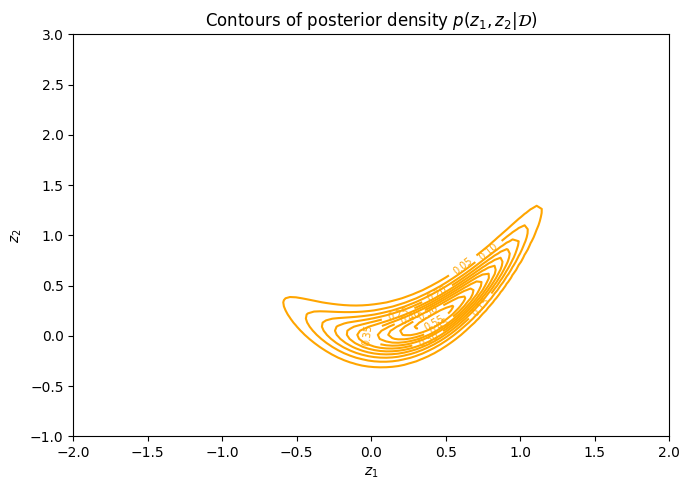

Note the banana shape: the posterior probability mass curves along z2 ≈ z1^2


In [15]:
# Question 5.1 — Contour plot of the posterior density
def log_target(z1, z2):
    """Log posterior up to a constant (eq. 9)."""
    return -(1 - z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2

z1s = np.linspace(-2,  2, 100)
z2s = np.linspace(-1,  3, 100)
Z1, Z2 = np.meshgrid(z1s, z2s)
LOG_P  = log_target(Z1, Z2)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contour(Z1, Z2, np.exp(LOG_P), levels=12, colors='orange')
ax.clabel(cs, inline=True, fontsize=7)
ax.set(xlabel='$z_1$', ylabel='$z_2$',
       title='Contours of posterior density $p(z_1,z_2|\mathcal{D})$')
plt.tight_layout()
plt.show()
print("Note the banana shape: the posterior probability mass curves along z2 ≈ z1^2")


##### **Question 5.2: Run the Metropolis sampler, discard warm-up, plot traces.**

The **Metropolis algorithm** is the simplest MCMC method. At each step:
1. Propose a new point $z^* \sim q(z^*|z^{(k-1)}) = \mathcal{N}(z^*|z^{(k-1)}, I)$ (random walk)
2. Accept with probability $\alpha = \min\!\left(1,\; \dfrac{p(z^*|\mathcal{D})}{p(z^{(k-1)}|\mathcal{D})}\right)$

<span style="color: orange;">

In log-space (numerically stable): accept if $\log U < \log p(z^*) - \log p(z^{(k-1)})$, where $U \sim \text{Uniform}(0,1)$.

</span>

Key settings:
- **$10^4$ iterations**: total chain length
- **Warm-up (10%)**: the first 1000 samples are discarded because the chain may not have reached the high-probability region yet (it starts at $(0, 1.5)$)
- **Proposal std $\tau=1$**: step size — too small means slow exploration, too large means many rejections

A good acceptance rate for Metropolis is typically 20–40%. The banana shape makes this target challenging.

Acceptance rate: 0.09  (9%)
Samples after discarding 1000 warm-up: 9000



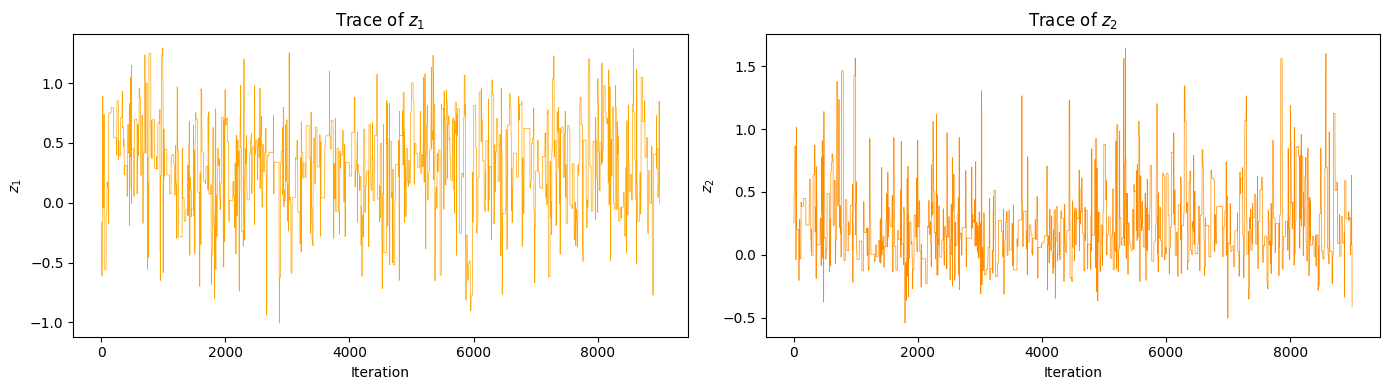

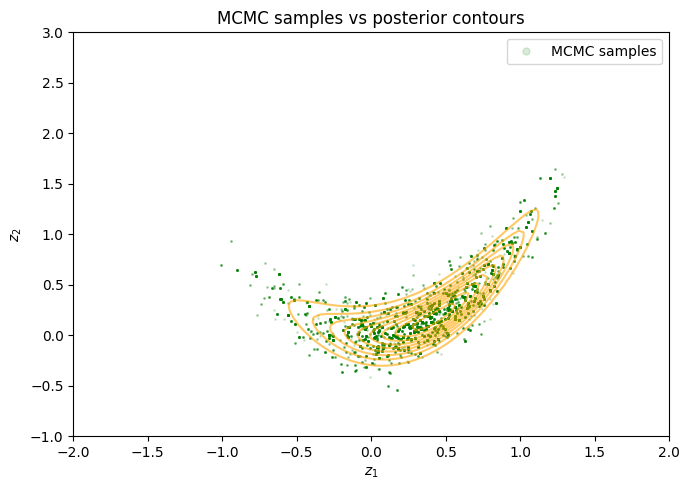

In [16]:
# Question 5.2 — Metropolis sampler
def metropolis(log_target_fn, theta_init, num_iter, tau=1.0, seed=42):
    """Simple Metropolis algorithm with isotropic Gaussian proposal."""
    rng     = np.random.default_rng(seed)
    D       = len(theta_init)
    samples = np.zeros((num_iter, D))
    samples[0] = theta_init
    n_accepted  = 0

    for k in range(1, num_iter):
        z_cur  = samples[k-1]
        z_prop = z_cur + rng.normal(0, tau, D)  # propose: random walk step

        # Log-acceptance ratio (symmetric proposal cancels, so just log p ratio)
        log_ratio = log_target_fn(z_prop) - log_target_fn(z_cur)

        # Accept with probability min(1, exp(log_ratio))
        if np.log(rng.uniform()) < log_ratio:
            samples[k] = z_prop
            n_accepted += 1
        else:
            samples[k] = z_cur   # stay in place

    acc_rate = n_accepted / (num_iter - 1)
    return samples, acc_rate

num_iter   = 10_000
warmup     = int(0.1 * num_iter)   # discard first 10%

samples, acc_rate = metropolis(
    log_target_fn = lambda z: log_target(z[0], z[1]),
    theta_init    = [0.0, 1.5],
    num_iter      = num_iter,
    tau           = 1.0
)
thetas = samples[warmup:]    # posterior samples after warm-up

print(f"Acceptance rate: {acc_rate:.2f}  ({acc_rate*100:.0f}%)")
print(f"Samples after discarding {warmup} warm-up: {len(thetas)}")
print()

# Trace plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(thetas[:, 0], lw=0.5, color='orange')
axes[0].set(xlabel='Iteration', ylabel='$z_1$', title='Trace of $z_1$')
axes[1].plot(thetas[:, 1], lw=0.5, color='darkorange')
axes[1].set(xlabel='Iteration', ylabel='$z_2$', title='Trace of $z_2$')
plt.tight_layout(); plt.show()

# Overlay samples on contours
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thetas[:, 0], thetas[:, 1], '.', alpha=0.15, ms=2, color='green', label='MCMC samples')
ax.contour(Z1, Z2, np.exp(LOG_P), levels=10, alpha=0.6, colors='orange')
ax.set(xlabel='$z_1$', ylabel='$z_2$', title='MCMC samples vs posterior contours')
ax.legend(markerscale=5); plt.tight_layout(); plt.show()


##### **Question 5.3: Estimate the posterior mean of $\sin(z_1 z_2)$ using the samples.**

**Monte Carlo integration** approximates intractable expectations using samples from the target distribution. If $z^{(1)}, \ldots, z^{(S)} \sim p(z|\mathcal{D})$, then:

<span style="color: orange;">

$$\mathbb{E}[g(z)|\mathcal{D}] = \int g(z)\,p(z|\mathcal{D})\,dz \approx \frac{1}{S}\sum_{i=1}^S g(z^{(i)})$$

</span>

This is the **Law of Large Numbers** — the sample average converges to the expectation as $S \to \infty$.

For $g(z) = \sin(z_1 z_2)$:
$$\mathbb{E}[\sin(z_1 z_2)|\mathcal{D}] \approx \frac{1}{S}\sum_{i=1}^S \sin(z_1^{(i)} z_2^{(i)})$$

In [17]:
# Question 5.3 — Posterior mean of sin(z1 * z2)
z1, z2 = thetas[:, 0], thetas[:, 1]
sin_vals = np.sin(z1 * z2)

mean_sin = np.mean(sin_vals)
se_sin   = np.std(sin_vals) / np.sqrt(len(sin_vals))   # standard error

print(f"E[sin(z1*z2) | D] ≈ {mean_sin:.2f}  (std error: ±{se_sin:.4f})")
print(f"Based on {len(thetas)} posterior samples")


E[sin(z1*z2) | D] ≈ 0.13  (std error: ±0.0026)
Based on 9000 posterior samples


##### **Question 5.4: Estimate the posterior probability $p(z_1 > z_2|\mathcal{D})$ using the samples.**

This is another Monte Carlo integral, but for a probability rather than an expectation. Using the indicator function $\mathbb{1}[\cdot]$:

<span style="color: orange;">

$$p(z_1 > z_2|\mathcal{D}) = \mathbb{E}[\mathbb{1}[z_1 > z_2]\,|\,\mathcal{D}] \approx \frac{1}{S}\sum_{i=1}^S \mathbb{1}[z_1^{(i)} > z_2^{(i)}]$$

</span>

In Python, `z1 > z2` returns a boolean array (True/False), and `np.mean` of booleans gives the fraction of True values — which is exactly the empirical probability.

In [18]:
# Question 5.4 — Posterior probability p(z1 > z2 | D)
indicator = z1 > z2                  # boolean array: True where z1 > z2
prob      = np.mean(indicator)        # fraction of samples where z1 > z2
se_prob   = np.sqrt(prob*(1-prob)/len(thetas))   # Bernoulli std error

print(f"p(z1 > z2 | D) ≈ {prob:.2f}  (std error: ±{se_prob:.4f})")
print(f"Based on {len(thetas)} samples, of which {np.sum(indicator)} had z1 > z2")
print()
print("Sanity check from scatter plot: most posterior mass sits along z2 ≈ z1^2,")
print("so z1 > z2 is true roughly when z1 > z1^2, i.e. 0 < z1 < 1.")


p(z1 > z2 | D) ≈ 0.71  (std error: ±0.0048)
Based on 9000 samples, of which 6356 had z1 > z2

Sanity check from scatter plot: most posterior mass sits along z2 ≈ z1^2,
so z1 > z2 is true roughly when z1 > z1^2, i.e. 0 < z1 < 1.


---
## **Quick-Reference Card: All Key Formulas**

### Part 1 — Linear Gaussian Systems
| Formula | Use when |
|---------|---------|
| $\Sigma_{z\|y}^{-1} = \Sigma_z^{-1} + W^T\Sigma_y^{-1}W$ | Finding conditional covariance |
| $\mu_{z\|y} = \Sigma_{z\|y}[W^T\Sigma_y^{-1}(y-b)+\Sigma_z^{-1}\mu_z]$ | Finding conditional mean |
| $p(y) = \mathcal{N}(y\|W\mu_z+b,\Sigma_y+W\Sigma_z W^T)$ | Marginalising (integrating out $z$) |

### Part 2 — Gaussian Process Regression
| Formula | Meaning |
|---------|---------|
| $p(y\|f) = \mathcal{N}(y\|f, \sigma^2 I)$ | Likelihood |
| $p(y^*\|x^*) = \mathcal{N}(y^*\|0, k(x^*,x^*)+\sigma^2)$ | Prior predictive |
| $p(y\|\theta) = \mathcal{N}(y\|0, K+\sigma^2 I)$ | Marginal likelihood |
| $\mu_{f^*\|y} = k_*(K+\sigma^2 I)^{-1}y$ | Posterior mean |
| $\sigma^2_{f^*\|y} = k_{**} - k_*(K+\sigma^2 I)^{-1}k_*^T$ | Posterior variance |
| $\sigma^2_{y^*\|y} = \sigma^2_{f^*\|y} + \sigma^2$ | Add noise for predictive |

### Part 3 — Binary Classification
| Formula | Use when |
|---------|---------|
| $p(y^*) \approx \text{Ber}(y^*\|\sigma(\hat{w}^T\phi^*))$ | Plug-in approximation |
| $p(f^*) = \mathcal{N}(f^*\|\hat{w}^T\phi^*, (\phi^*)^TS\phi^*)$ | Laplace posterior of $f^*$ |
| $p(y^*=1) \approx \Phi(\mu_{f^*}/\sqrt{8/\pi+\sigma^2_{f^*}})$ | Probit approximation |
| $\mathbb{E}[U] = \sum_{y} p(y^*)U(y,\hat{y})$ | Expected utility |

### Part 4 — Variational Inference
| Formula | Use when |
|---------|---------|
| $H[\mathcal{N}(m,v)] = \frac{1}{2}\ln(2\pi e v)$ | Gaussian entropy |
| $\mathbb{E}[w] = m,\quad \mathbb{E}[w^2] = m^2 + v$ | Gaussian moments |
| $\mathbb{E}[w_1 w_2] = m_1 m_2$ under mean-field | Independence of factors |
| $\text{Cov}_{q^*}(w_1,w_2) = 0$ | Mean-field always gives zero covariance |

### Part 5 — MCMC
| Formula | Use when |
|---------|---------|
| Accept if $\log U < \log p(z^*) - \log p(z^{\text{cur}})$ | Metropolis step |
| $\mathbb{E}[g(z)] \approx \frac{1}{S}\sum_i g(z^{(i)})$ | MC integration |
| $p(\text{event}) \approx \frac{1}{S}\sum_i \mathbb{1}[\text{event at } z^{(i)}]$ | MC probability estimate |